In [ ]:
from prophet import Prophet
import numpy as np
import joblib
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules
from google.colab import files
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [ ]:
import warnings
warnings.filterwarnings(
    "ignore",
    category=DeprecationWarning
)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
df=pd.read_excel("Online Retail.xlsx")

In [ ]:
print(df.info())
print(df.shape)
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  object        
 1   StockCode    397884 non-null  object        
 2   Description  397884 non-null  object        
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[ns]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  float64       
 7   Country      397884 non-null  object        
 8   Revenue      397884 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 30.4+ MB
None
(397884, 9)
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
Revenue        0
dtype: int64


# DATA CLEANING

In [ ]:
df = df.dropna(subset=["CustomerID"])
print(df.shape)

(397884, 9)


In [ ]:
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]
df = df[df["Quantity"] > 0]
df = df[df["UnitPrice"] > 0]

REVENUE COLUMN

In [ ]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

In [ ]:
df[["Quantity","UnitPrice","Revenue"]].head()

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [ ]:
print(df.describe())
print(df.isnull().sum())
print(df.shape)

            Quantity                    InvoiceDate      UnitPrice  \
count  397884.000000                         397884  397884.000000   
mean       12.988238  2011-07-10 23:41:23.511023360       3.116488   
min         1.000000            2010-12-01 08:26:00       0.001000   
25%         2.000000            2011-04-07 11:12:00       1.250000   
50%         6.000000            2011-07-31 14:39:00       1.950000   
75%        12.000000            2011-10-20 14:33:00       3.750000   
max     80995.000000            2011-12-09 12:50:00    8142.750000   
std       179.331775                            NaN      22.097877   

          CustomerID        Revenue  
count  397884.000000  397884.000000  
mean    15294.423453      22.397000  
min     12346.000000       0.001000  
25%     13969.000000       4.680000  
50%     15159.000000      11.800000  
75%     16795.000000      19.800000  
max     18287.000000  168469.600000  
std      1713.141560     309.071041  
InvoiceNo      0
StockCode 

Exploratory Anlysis(EDA)

In [ ]:
print("Total Revenue:", round(df["Revenue"].sum(),2))
print("Unique Customers:", df["CustomerID"].nunique())
print("Unique Products:", df["Description"].nunique())
print("Average Order Value:",
      round(df["Revenue"].sum()/df["InvoiceNo"].nunique(),2))

Total Revenue: 8911407.9
Unique Customers: 4338
Unique Products: 3877
Average Order Value: 480.87


In [ ]:
top_products = df.groupby("Description")["Quantity"].sum()

top_products.sort_values(
    ascending=False
).head(10)

,Quantity
Description,
"PAPER CRAFT , LITTLE BIRDIE",80995
MEDIUM CERAMIC TOP STORAGE JAR,77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS,54415
JUMBO BAG RED RETROSPOT,46181
WHITE HANGING HEART T-LIGHT HOLDER,36725
ASSORTED COLOUR BIRD ORNAMENT,35362
PACK OF 72 RETROSPOT CAKE CASES,33693
POPCORN HOLDER,30931
RABBIT NIGHT LIGHT,27202


In [ ]:
country_sales = df.groupby("Country")["Revenue"].sum()

country_sales.sort_values(
    ascending=False
).head(10)

,Revenue
Country,
United Kingdom,7308391.554
Netherlands,285446.340
EIRE,265545.900
Germany,228867.140
France,209024.050
Australia,138521.310
Spain,61577.110
Switzerland,56443.950
Belgium,41196.340


In [ ]:
print(df.shape)
print(df.head())

(397884, 9)
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  Revenue  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom    15.30  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom    20.34  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom    22.00  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom    20.34  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom    20.34  


# RFM Table

In [ ]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [ ]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

In [ ]:
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo": "nunique",
    "Revenue": "sum"
}).reset_index()

rfm.columns = ["CustomerID","Recency", "Frequency", "Monetary"]

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [ ]:
rfm.shape
rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2054.266460
std,1721.808492,100.014169,7.697998,8989.230441
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,307.415000
50%,15299.500000,51.000000,2.000000,674.485000
75%,16778.750000,142.000000,5.000000,1661.740000
max,18287.000000,374.000000,209.000000,280206.020000


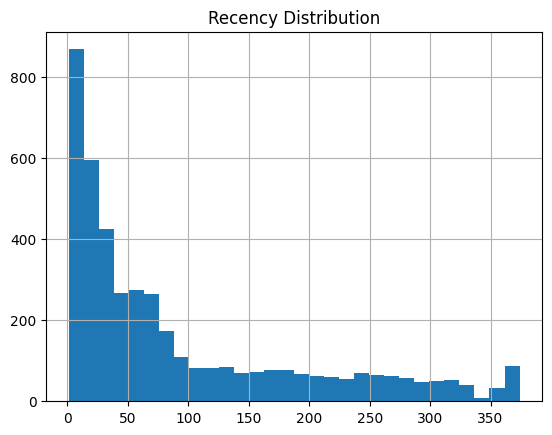

In [ ]:
# rfm["Recency"].hist(bins=30)

# plt.title("Recency Distribution")
# plt.show()

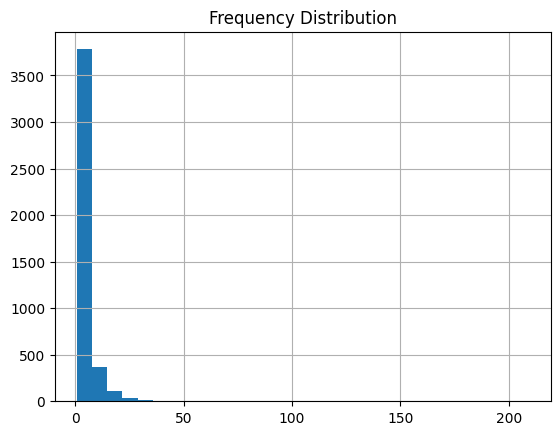

In [ ]:
# rfm["Frequency"].hist(bins=30)

# plt.title("Frequency Distribution")
# plt.show()

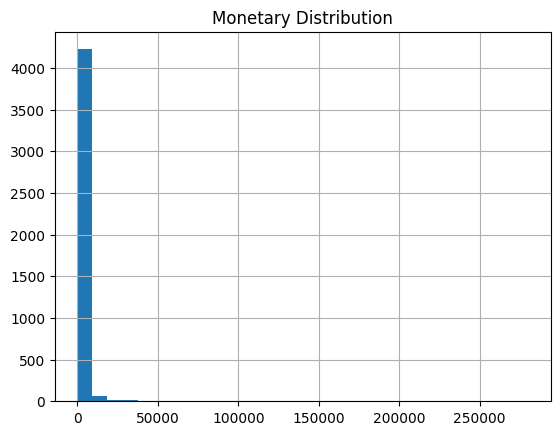

In [ ]:
# rfm["Monetary"].hist(bins=30)

# plt.title("Monetary Distribution")
# plt.show()

#Customer Segmentation (K-Means)

In [ ]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm[["Recency","Frequency","Monetary"]]
)

In [ ]:
inertia = []

for k in range(1,11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    kmeans.fit(rfm_scaled)

    inertia.append(kmeans.inertia_)

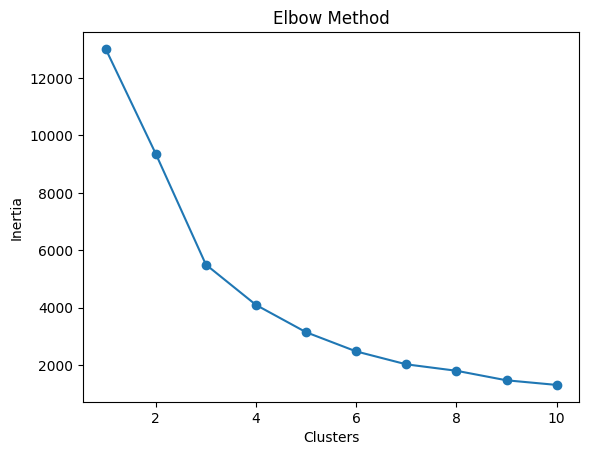

In [ ]:
plt.plot(range(1,11), inertia, marker="o")

plt.xlabel("Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

Train

In [ ]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

In [ ]:
rfm.head()
rfm["Cluster"].value_counts()

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346.0,326,1,77183.60,3
1,12347.0,2,7,4310.00,0
2,12348.0,75,4,1797.24,0
3,12349.0,19,1,1757.55,0
4,12350.0,310,1,334.40,1


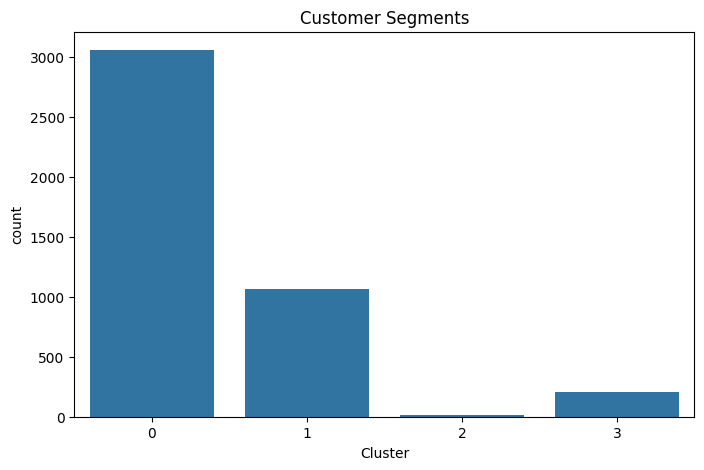

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=rfm,
    x="Cluster"
)

plt.title("Customer Segments")
plt.show()

In [ ]:
cluster_summary = rfm.groupby("Cluster").agg({
    "Recency":"mean",
    "Frequency":"mean",
    "Monetary":"mean"
}).round(2)

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,43.70,3.68,1359.05
1,248.08,1.55,480.62
2,7.38,82.54,127338.31
3,15.50,22.33,12709.09


In [ ]:
rfm.shape

(4338, 5)

In [ ]:
segment_names = {
    0: "Regular",
    1: "At Risk",
    2: "VIP",
    3: "Loyal"
}

rfm["Segment"] = rfm["Cluster"].map(segment_names)


In [ ]:
joblib.dump(kmeans,"kmeans.pkl")
joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']

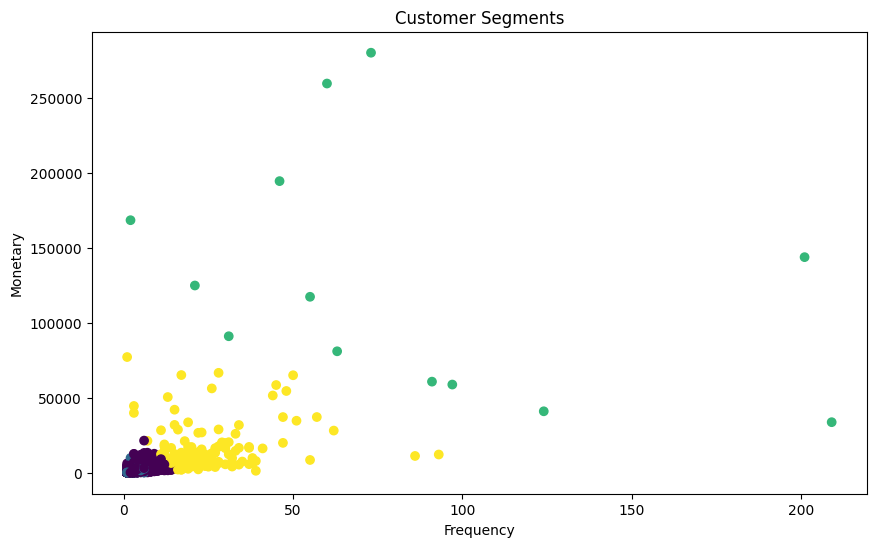

In [ ]:
plt.figure(figsize=(10,6))

plt.scatter(
    rfm["Frequency"],
    rfm["Monetary"],
    c=rfm["Cluster"]
)

plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.title("Customer Segments")

plt.show()

# Churn Prediction

In [ ]:
customer_features = df.groupby("CustomerID").agg({
    "Revenue":"sum",
    "Quantity":"sum",
    "StockCode":"nunique",
    "InvoiceNo":"nunique"
}).reset_index()

customer_features.columns = [
    "CustomerID",
    "TotalRevenue",
    "TotalQuantity",
    "UniqueProducts",
    "Frequency"
]

In [ ]:
customer_features = pd.merge(
    rfm,
    customer_features,
    on="CustomerID"
)

In [ ]:
customer_features["Churn"] = (
    customer_features["Recency"] > 90
).astype(int)

In [ ]:
customer_features["Churn"].value_counts()

,count
Churn,
0,2889
1,1449


In [ ]:
customer_features = customer_features.drop(
    columns=["Frequency_y"]
)

customer_features = customer_features.rename(
    columns={
        "Frequency_x":"Frequency"
    }
)

In [ ]:
X = customer_features[
    [
        "Frequency",
        "Monetary",
        "TotalRevenue",
        "TotalQuantity",
        "UniqueProducts"
    ]
]

y = customer_features["Churn"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [ ]:
preds = rf.predict(X_test)

print(classification_report(y_test,preds))

              precision    recall  f1-score   support

           0       0.72      0.83      0.77       561
           1       0.58      0.41      0.48       307

    accuracy                           0.69       868
   macro avg       0.65      0.62      0.63       868
weighted avg       0.67      0.69      0.67       868



In [ ]:
joblib.dump(rf,"churn_model.pkl")

['churn_model.pkl']

#Recommendation Engine
(used Apriori to find patterns)

In [ ]:
df["Description"].nunique()

3877

In [ ]:
product_counts = df["Description"].value_counts()

popular_products = product_counts[
    product_counts >= 200
].index

df_apriori = df[
    df["Description"].isin(popular_products)
]

print(df_apriori["Description"].nunique())

584


In [ ]:
basket = (
    df_apriori
    .groupby(["InvoiceNo","Description"])["Quantity"]
    .sum()
    .unstack()
    .fillna(0)
)

In [ ]:
basket = basket.applymap(
    lambda x: 1 if x > 0 else 0
)

/tmp/ipykernel_8543/913560628.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket = basket.applymap(


In [ ]:
basket.shape
basket.head()

Description,SET 2 TEA TOWELS I LOVE LONDON,10 COLOUR SPACEBOY PEN,12 MESSAGE CARDS WITH ENVELOPES,12 PENCIL SMALL TUBE WOODLAND,12 PENCILS SMALL TUBE RED RETROSPOT,12 PENCILS SMALL TUBE SKULL,12 PENCILS TALL TUBE RED RETROSPOT,12 PENCILS TALL TUBE SKULLS,12 PENCILS TALL TUBE WOODLAND,15CM CHRISTMAS GLASS BALL 20 LIGHTS,...,WOODEN TREE CHRISTMAS SCANDINAVIAN,WOODEN UNION JACK BUNTING,WOODLAND CHARLOTTE BAG,WORLD WAR 2 GLIDERS ASSTD DESIGNS,WRAP ALPHABET DESIGN,WRAP ENGLISH ROSE,YOU'RE CONFUSING ME METAL SIGN,ZINC FOLKART SLEIGH BELLS,ZINC METAL HEART DECORATION,ZINC T-LIGHT HOLDER STARS SMALL
InvoiceNo,,,,,,,,,,,,,,,,,,,,,
536365,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536366,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536367,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536368,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536369,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
frequent_items = apriori(
    basket,
    min_support=0.02,
    use_colnames=True
)

In [ ]:
frequent_items.sort_values(
    "support",
    ascending=False
).head(20)

,support,itemsets
211,0.111646,(WHITE HANGING HEART T-LIGHT HOLDER)
168,0.096465,(REGENCY CAKESTAND 3 TIER)
90,0.090631,(JUMBO BAG RED RETROSPOT)
135,0.078113,(PARTY BUNTING)
14,0.077886,(ASSORTED COLOUR BIRD ORNAMENT)
112,0.072958,(LUNCH BAG RED RETROSPOT)
182,0.064914,(SET OF 3 CAKE TINS PANTRY DESIGN )
151,0.062252,(POSTAGE)
105,0.059590,(LUNCH BAG BLACK SKULL.)
127,0.058287,(PACK OF 72 RETROSPOT CAKE CASES)


In [ ]:
rules = association_rules(
    frequent_items,
    metric="confidence",
    min_threshold=0.4
)
print(rules.shape)

(61, 14)


In [ ]:
rules.sort_values(
    by="lift",
    ascending=False
).head(20)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
55,"(GREEN REGENCY TEACUP AND SAUCER, ROSES REGENC...",(PINK REGENCY TEACUP AND SAUCER),0.030645,0.031494,0.022091,0.720887,22.889467,1.0,0.021126,3.469944,0.986544,0.551627,0.711811,0.711163
60,(PINK REGENCY TEACUP AND SAUCER),"(GREEN REGENCY TEACUP AND SAUCER, ROSES REGENC...",0.031494,0.030645,0.022091,0.701439,22.889467,1.0,0.021126,3.246757,0.987410,0.551627,0.692000,0.711163
57,"(PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY...",(GREEN REGENCY TEACUP AND SAUCER),0.024697,0.039141,0.022091,0.894495,22.852999,1.0,0.021125,9.107270,0.980456,0.529172,0.890198,0.729447
58,(GREEN REGENCY TEACUP AND SAUCER),"(PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY...",0.039141,0.024697,0.022091,0.564399,22.852999,1.0,0.021125,2.238985,0.995195,0.529172,0.553369,0.729447
8,(GREEN REGENCY TEACUP AND SAUCER),(PINK REGENCY TEACUP AND SAUCER),0.039141,0.031494,0.026056,0.665702,21.137232,1.0,0.024824,2.897132,0.991499,0.584498,0.654831,0.746520
9,(PINK REGENCY TEACUP AND SAUCER),(GREEN REGENCY TEACUP AND SAUCER),0.031494,0.039141,0.026056,0.827338,21.137232,1.0,0.024824,5.564973,0.983670,0.584498,0.820305,0.746520
56,"(GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY...",(ROSES REGENCY TEACUP AND SAUCER ),0.026056,0.044353,0.022091,0.847826,19.115609,1.0,0.020936,6.279969,0.973041,0.457210,0.840764,0.672955
59,(ROSES REGENCY TEACUP AND SAUCER ),"(GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY...",0.044353,0.026056,0.022091,0.498084,19.115609,1.0,0.020936,1.940452,0.991670,0.457210,0.484656,0.672955
49,(ROSES REGENCY TEACUP AND SAUCER ),(PINK REGENCY TEACUP AND SAUCER),0.044353,0.031494,0.024697,0.556833,17.680440,1.0,0.023300,2.185418,0.987226,0.482835,0.542422,0.670503
50,(PINK REGENCY TEACUP AND SAUCER),(ROSES REGENCY TEACUP AND SAUCER ),0.031494,0.044353,0.024697,0.784173,17.680440,1.0,0.023300,4.427833,0.974120,0.482835,0.774156,0.670503


In [ ]:
rules = rules[
    [
        "antecedents",
        "consequents",
        "support",
        "confidence",
        "lift"
    ]
]

In [ ]:
rules.to_csv(
    "recommendation_rules.csv",
    index=False
)

In [ ]:
print(df["Description"].nunique())
print(df_apriori["Description"].nunique())
product_counts.describe()
basket.shape

3877
584


(17654, 584)

In [ ]:
frequent_items = apriori(
    basket,
    min_support=0.02,
    use_colnames=True
)

print(frequent_items.shape)

frequent_items.sort_values(
    by="support",
    ascending=False
).head(20)

(268, 2)


,support,itemsets
211,0.111646,(WHITE HANGING HEART T-LIGHT HOLDER)
168,0.096465,(REGENCY CAKESTAND 3 TIER)
90,0.090631,(JUMBO BAG RED RETROSPOT)
135,0.078113,(PARTY BUNTING)
14,0.077886,(ASSORTED COLOUR BIRD ORNAMENT)
112,0.072958,(LUNCH BAG RED RETROSPOT)
182,0.064914,(SET OF 3 CAKE TINS PANTRY DESIGN )
151,0.062252,(POSTAGE)
105,0.059590,(LUNCH BAG BLACK SKULL.)
127,0.058287,(PACK OF 72 RETROSPOT CAKE CASES)


In [ ]:
rules = association_rules(
    frequent_items,
    metric="confidence",
    min_threshold=0.4
)

rules = rules.sort_values(
    by="lift",
    ascending=False
)

print(rules.shape)

(61, 14)


In [ ]:
rules[
    [
        "antecedents",
        "consequents",
        "support",
        "confidence",
        "lift"
    ]
].head(20)

,antecedents,consequents,support,confidence,lift
55,"(GREEN REGENCY TEACUP AND SAUCER, ROSES REGENC...",(PINK REGENCY TEACUP AND SAUCER),0.022091,0.720887,22.889467
60,(PINK REGENCY TEACUP AND SAUCER),"(GREEN REGENCY TEACUP AND SAUCER, ROSES REGENC...",0.022091,0.701439,22.889467
57,"(PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY...",(GREEN REGENCY TEACUP AND SAUCER),0.022091,0.894495,22.852999
58,(GREEN REGENCY TEACUP AND SAUCER),"(PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY...",0.022091,0.564399,22.852999
8,(GREEN REGENCY TEACUP AND SAUCER),(PINK REGENCY TEACUP AND SAUCER),0.026056,0.665702,21.137232
9,(PINK REGENCY TEACUP AND SAUCER),(GREEN REGENCY TEACUP AND SAUCER),0.026056,0.827338,21.137232
56,"(GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY...",(ROSES REGENCY TEACUP AND SAUCER ),0.022091,0.847826,19.115609
59,(ROSES REGENCY TEACUP AND SAUCER ),"(GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY...",0.022091,0.498084,19.115609
49,(ROSES REGENCY TEACUP AND SAUCER ),(PINK REGENCY TEACUP AND SAUCER),0.024697,0.556833,17.680440
50,(PINK REGENCY TEACUP AND SAUCER),(ROSES REGENCY TEACUP AND SAUCER ),0.024697,0.784173,17.680440


# Demand Forecasting

In [ ]:
sales = df.groupby(
    pd.Grouper(
        key="InvoiceDate",
        freq="D"
    )
)["Revenue"].sum().reset_index()

sales.columns = ["ds", "y"]

sales.head()

,ds,y
0,2010-12-01,46376.49
1,2010-12-02,47316.53
2,2010-12-03,23921.71
3,2010-12-04,0.00
4,2010-12-05,31771.60


In [ ]:
sales.shape
sales.head()

,ds,y
0,2010-12-01,46376.49
1,2010-12-02,47316.53
2,2010-12-03,23921.71
3,2010-12-04,0.00
4,2010-12-05,31771.60


In [ ]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True
)

model.fit(sales)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
future = model.make_future_dataframe(
    periods=30
)

future.tail()

,ds
399,2012-01-04
400,2012-01-05
401,2012-01-06
402,2012-01-07
403,2012-01-08


In [ ]:
forecast = model.predict(future)

forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2010-12-01,10252.308868,14260.878404,46993.025553,10252.308868,10252.308868,19585.874538,19585.874538,19585.874538,5568.505981,5568.505981,5568.505981,14017.368557,14017.368557,14017.368557,0.0,0.0,0.0,29838.183405
1,2010-12-02,10321.751264,22716.385646,54990.052958,10321.751264,10321.751264,27962.048979,27962.048979,27962.048979,12668.583932,12668.583932,12668.583932,15293.465047,15293.465047,15293.465047,0.0,0.0,0.0,38283.800244
2,2010-12-03,10391.193661,12636.118507,46175.354930,10391.193661,10391.193661,19929.517743,19929.517743,19929.517743,3488.656288,3488.656288,3488.656288,16440.861455,16440.861455,16440.861455,0.0,0.0,0.0,30320.711404
3,2010-12-04,10460.636058,-12804.990345,21425.709153,10460.636058,10460.636058,-6086.764389,-6086.764389,-6086.764389,-23515.780758,-23515.780758,-23515.780758,17429.016368,17429.016368,17429.016368,0.0,0.0,0.0,4373.871669
4,2010-12-05,10530.078455,2383.198135,36929.132046,10530.078455,10530.078455,9582.528572,9582.528572,9582.528572,-8647.877240,-8647.877240,-8647.877240,18230.405811,18230.405811,18230.405811,0.0,0.0,0.0,20112.607027


In [ ]:
forecast[
    ["ds","yhat","yhat_lower","yhat_upper"]
].tail(30)

,ds,yhat,yhat_lower,yhat_upper
374,2011-12-10,31951.874331,15409.544306,48803.886930
375,2011-12-11,46308.580252,30682.188934,62735.292963
376,2011-12-12,56310.743317,39794.411684,72687.801228
377,2011-12-13,61533.185346,44733.992970,77630.568682
378,2011-12-14,57570.375578,41680.927889,73808.215006
379,2011-12-15,63274.721002,46303.787310,79499.348171
380,2011-12-16,52537.739097,36359.293042,70308.339669
381,2011-12-17,23847.808150,7431.935324,39901.105024
382,2011-12-18,36937.907656,19121.405502,54033.502898
383,2011-12-19,45866.331425,29022.522643,63337.887980


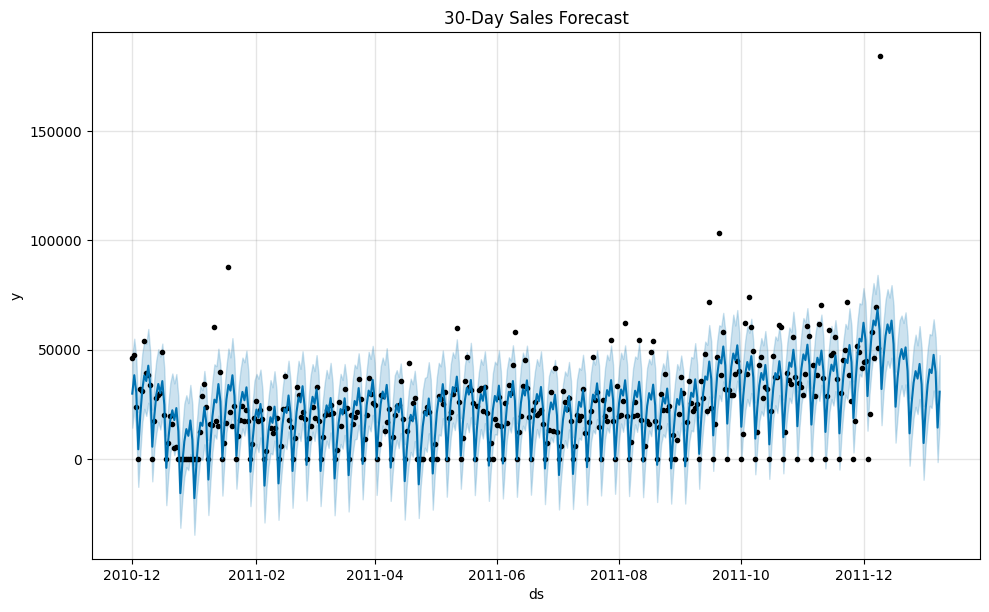

In [ ]:
fig = model.plot(forecast)
plt.title("30-Day Sales Forecast")
plt.show()

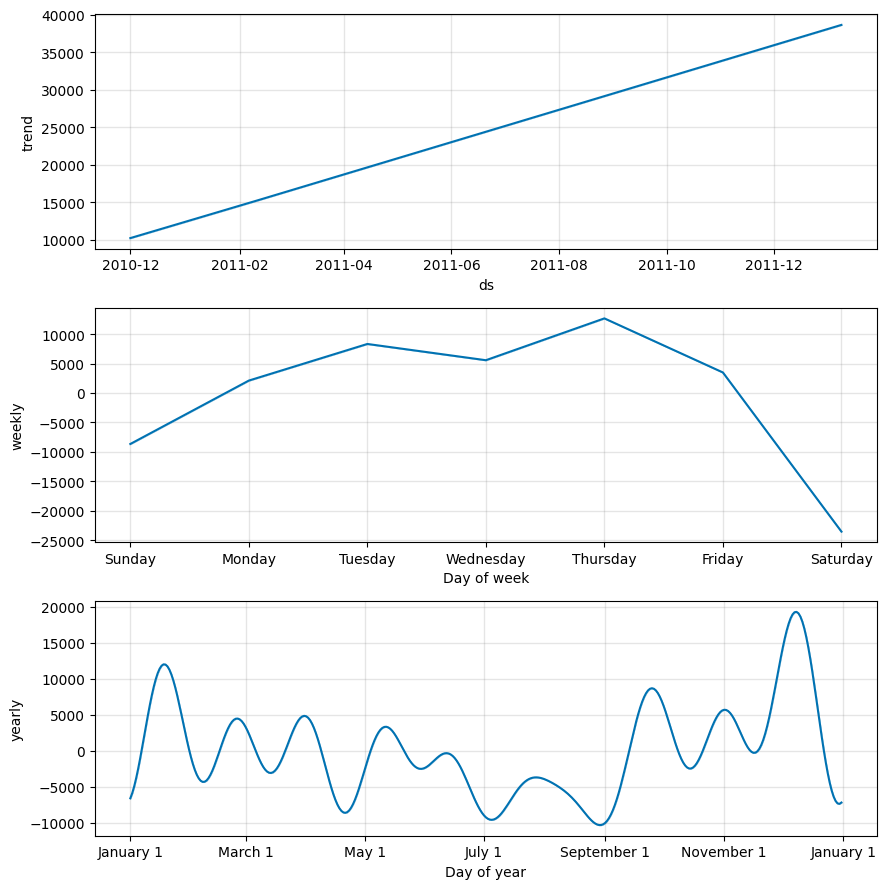

In [ ]:
fig2 = model.plot_components(forecast)
plt.show()

In [ ]:
joblib.dump(
    model,
    "forecast_model.pkl"
)

['forecast_model.pkl']

In [ ]:
joblib.dump(
    kmeans,
    "kmeans.pkl"
)

joblib.dump(
    scaler,
    "scaler.pkl"
)

joblib.dump(
    rf,
    "churn_model.pkl"
)

joblib.dump(
    model,
    "forecast_model.pkl"
)

rules.to_csv(
    "recommendation_rules.csv",
    index=False
)

print("All models saved successfully.")

All models saved successfully.


In [ ]:
rfm.to_csv(
    "customer_segments.csv",
    index=False
)

In [ ]:
customer_features["ChurnRisk"] = rf.predict_proba(X)[:,1]

customer_features.to_csv(
    "customer_churn.csv",
    index=False
)

In [ ]:
cluster_summary.to_csv(
    "cluster_summary.csv"
)

In [ ]:
forecast[
    [
        "ds",
        "yhat",
        "yhat_lower",
        "yhat_upper"
    ]
].to_csv(
    "sales_forecast.csv",
    index=False
)

In [ ]:
print("Segments:", rfm.shape)

print("Customers:",
      customer_features.shape)

print("Forecast Rows:",
      forecast.shape)

print("Rules:",
      rules.shape)

Segments: (4338, 6)
Customers: (4338, 11)
Forecast Rows: (404, 19)
Rules: (61, 14)
